In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import pickle
import os

# Load clean dataset
df = pd.read_csv("C:/Projects/pune-rent-predictor/data/pune_rent_clean.csv")

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset loaded!
Shape: (7550, 10)

Columns: ['Area_sqft', 'Location', 'BHK', 'Parking', 'Gym', 'Pool', 'Lift', 'PowerBackup', 'AC', 'Rent_Monthly']


,Area_sqft,Location,BHK,Parking,Gym,Pool,Lift,PowerBackup,AC,Rent_Monthly
0,720,Hadapsar,1,1,0,0,1,1,0,14600.0
1,600,Hadapsar,1,1,1,1,1,1,0,13500.0
2,650,Hadapsar,1,1,1,1,1,1,0,20100.0
3,650,Hadapsar,1,1,0,0,1,1,1,13500.0
4,665,Hadapsar,1,1,0,0,1,1,0,15000.0


In [2]:
# Step 1 — Encode Location (convert text to numbers)
le = LabelEncoder()
df['Location_encoded'] = le.fit_transform(df['Location'])

# Step 2 — Define features (X) and target (y)
feature_columns = ['Area_sqft', 'Location_encoded', 'BHK', 
                   'Parking', 'Gym', 'Pool', 'Lift', 'PowerBackup', 'AC']

X = df[feature_columns]
y = df['Rent_Monthly']

# Step 3 — Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"\nFeatures used: {feature_columns}")
print(f"\nRent range in training data:")
print(f"  Min: ₹{int(y_train.min()):,}")
print(f"  Max: ₹{int(y_train.max()):,}")
print(f"  Avg: ₹{int(y_train.mean()):,}")

Training samples: 6040
Testing samples:  1510

Features used: ['Area_sqft', 'Location_encoded', 'BHK', 'Parking', 'Gym', 'Pool', 'Lift', 'PowerBackup', 'AC']

Rent range in training data:
  Min: ₹6,000
  Max: ₹199,800
  Avg: ₹38,701


In [3]:
# Train XGBoost model
print("Training XGBoost model...")

model = xgb.XGBRegressor(
    n_estimators=300,        # 300 decision trees
    learning_rate=0.05,      # how fast to learn
    max_depth=6,             # how deep each tree goes
    subsample=0.8,           # use 80% of data per tree
    colsample_bytree=0.8,    # use 80% of features per tree
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50               # print progress every 50 trees
)

print("\nTraining complete! 🎉")

Training XGBoost model...
[0]	validation_0-rmse:32466.29422
[50]	validation_0-rmse:28995.99242
[100]	validation_0-rmse:28600.34375
[150]	validation_0-rmse:28543.25881
[200]	validation_0-rmse:28546.32779
[250]	validation_0-rmse:28567.77571
[299]	validation_0-rmse:28654.35287

Training complete! 🎉


In [4]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate scores
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL PERFORMANCE REPORT")
print("=" * 40)
print(f"MAE  (avg error):     ₹{int(mae):,}")
print(f"R²   (accuracy):      {r2:.4f} ({r2*100:.2f}%)")
print("=" * 40)

# Show 10 sample predictions vs actual
print("\nSample Predictions vs Actual:")
print(f"{'Actual':>12} {'Predicted':>12} {'Difference':>12}")
print("-" * 38)
for actual, predicted in zip(list(y_test[:10]), y_pred[:10]):
    diff = predicted - actual
    print(f"₹{int(actual):>10,} ₹{int(predicted):>10,} ₹{int(diff):>+10,}")

       MODEL PERFORMANCE REPORT
MAE  (avg error):     ₹18,675
R²   (accuracy):      0.2332 (23.32%)

Sample Predictions vs Actual:
      Actual    Predicted   Difference
--------------------------------------
₹    23,400 ₹    36,584 ₹   +13,184
₹    64,500 ₹    62,542 ₹    -1,957
₹     8,400 ₹    69,448 ₹   +61,048
₹    60,000 ₹    40,255 ₹   -19,744
₹    84,000 ₹    75,814 ₹    -8,185
₹    37,800 ₹    33,748 ₹    -4,051
₹    40,500 ₹    42,751 ₹    +2,251
₹    22,800 ₹    12,485 ₹   -10,314
₹    45,300 ₹    63,392 ₹   +18,092
₹     8,400 ₹    14,531 ₹    +6,131


In [5]:
# Create better features
df['Price_per_sqft'] = df['Rent_Monthly'] / df['Area_sqft']
df['Total_amenities'] = df['Gym'] + df['Pool'] + df['Lift'] + df['PowerBackup'] + df['AC'] + df['Parking']
df['BHK_Area'] = df['BHK'] * df['Area_sqft']

# Re-encode location
df['Location_encoded'] = le.fit_transform(df['Location'])

# New feature set
feature_columns = ['Area_sqft', 'Location_encoded', 'BHK',
                   'Total_amenities', 'BHK_Area',
                   'Parking', 'Gym', 'Pool', 'Lift', 'PowerBackup', 'AC']

X = df[feature_columns]
y = df['Rent_Monthly']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Retrain with better parameters
model2 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42
)

model2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluate
y_pred2 = model2.predict(X_test)
mae2 = mean_absolute_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("\n" + "=" * 40)
print("    IMPROVED MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  (avg error):  ₹{int(mae2):,}")
print(f"R²   (accuracy):   {r2_2:.4f} ({r2_2*100:.2f}%)")
print("=" * 40)

[0]	validation_0-rmse:32544.05165
[100]	validation_0-rmse:28669.29124
[200]	validation_0-rmse:28522.94679
[300]	validation_0-rmse:28684.90879
[400]	validation_0-rmse:28854.85145
[499]	validation_0-rmse:29032.93292

    IMPROVED MODEL PERFORMANCE
MAE  (avg error):  ₹18,865
R²   (accuracy):   0.2128 (21.28%)


In [6]:
# Load the new real rent dataset
df_new = pd.read_csv("C:/Projects/pune-rent-predictor/data/train.csv")

print("Shape:", df_new.shape)
print("\nColumns:", df_new.columns.tolist())
print("\nFirst 5 rows:")
df_new.head()

Shape: (10884, 30)

Columns: ['bedroom', 'bathrooms', 'area', 'furnishing', 'avalable_for', 'address', 'floor_number', 'facing', 'floor_type', 'gate_community', 'corner_pro', 'parking', 'wheelchairadption', 'petfacility', 'aggDur', 'noticeDur', 'lightbill', 'powerbackup', 'propertyage', 'no_room', 'pooja_room', 'study_room', 'others', 'servant_room', 'store_room', 'maintenance_amt', 'brok_amt', 'deposit_amt', 'mnt_amt', 'rent']

First 5 rows:


,bedroom,bathrooms,area,furnishing,avalable_for,address,floor_number,facing,floor_type,gate_community,...,pooja_room,study_room,others,servant_room,store_room,maintenance_amt,brok_amt,deposit_amt,mnt_amt,rent
0,2,2,1050.0,Unfurnished,All,"Sadguru hights, Pingale Wasti, , Pune, Maharas...",5,West,Marble,Yes,...,0,0,0,0,0,0,0,3,0.0,20000.0
1,2,2,760.0,Unfurnished,All,"Manav Silver Springs, Wagholi, , Pune, Maharas...",5,East,Vitrified,Yes,...,0,0,0,0,0,0,0,40000,0.0,14000.0
2,3,3,0.0,Semifurnished,All,"Saarrthi Souvenir, Mahalunge, , Pune, Maharashtra",1,South-West,Vitrified,Yes,...,0,0,1,0,0,Maintenance 1/ (/ month,23000,60000,1.0,22999.0
3,1,1,628.0,Furnished,Family Only,"Dhan Residency, Wanowrie, , Pune, Maharashtra",3,East,Mosaic,Yes,...,0,0,0,0,0,0,0,40000,0.0,13000.0
4,2,2,668.0,Semifurnished,"Family , Bachelors (Men Only)","Saptsiddhi Savali Homes, Uruli Devachi, , Pune...",6,South,Polished concrete,Yes,...,0,0,0,0,0,0,0,20,0.0,7500.0


In [7]:
# Explore the new dataset
print("=== RENT COLUMN ===")
print(df_new['rent'].describe())

print("\n=== BEDROOM ===")
print(df_new['bedroom'].value_counts().head(8))

print("\n=== TOP 10 LOCATIONS ===")
print(df_new['address'].value_counts().head(10))

print("\n=== FURNISHING ===")
print(df_new['furnishing'].value_counts())

print("\n=== MISSING VALUES ===")
missing = df_new.isnull().sum()
print(missing[missing > 0])

=== RENT COLUMN ===
count    1.088400e+04
mean     2.855947e+04
std      1.183249e+06
min      1.600000e+03
25%      1.050000e+04
50%      1.500000e+04
75%      2.100000e+04
max      1.234568e+08
Name: rent, dtype: float64

=== BEDROOM ===
bedroom
2     4936
1     4219
3     1504
4      202
5       17
7        2
22       1
10       1
Name: count, dtype: int64

=== TOP 10 LOCATIONS ===
address
Paranjape Blue Ridge, Hinjewadi, , Pune, Maharashtra           71
Kharadi, , Pune, Maharashtra                                   44
Hadapsar, , Pune, Maharashtra                                  39
Kolte Patil Life Republic, Hinjewadi, , Pune, Maharashtra      34
Bramhacorp F Residences, Kalyani Nagar, , Pune, Maharashtra    33
Rohan Abhilasha, Wagholi, , Pune, Maharashtra                  31
Kolte Patil Western Avenue, Wakad, , Pune, Maharashtra         31
Xrbia Hinjewadi, Hinjewadi, , Pune, Maharashtra                30
Wadgaon Sheri, , Pune, Maharashtra                             28
Xrbia City

In [8]:
# Step 1 — Drop columns with too many missing values
df_pune = df_new.drop(['wheelchairadption', 'petfacility'], axis=1)

# Step 2 — Drop rows with missing values
df_pune = df_pune.dropna()

# Step 3 — Remove outliers
# Bedrooms: only keep 1-6 BHK
df_pune = df_pune[df_pune['bedroom'].between(1, 6)]
# Rent: only keep ₹3,000 to ₹3,00,000
df_pune = df_pune[df_pune['rent'].between(3000, 300000)]

# Step 4 — Clean address to extract area name only
# "Kharadi, , Pune, Maharashtra" → "Kharadi"
df_pune['location'] = df_pune['address'].apply(
    lambda x: x.split(',')[0].strip()
)

# Step 5 — Clean furnishing column
df_pune['furnishing'] = df_pune['furnishing'].replace(
    'Unfurnishe', 'Unfurnished'
)

# Step 6 — Select final columns
df_final = df_pune[[
    'bedroom', 'bathrooms', 'area', 'furnishing',
    'floor_number', 'parking', 'powerbackup',
    'gate_community', 'location', 'rent'
]].copy()

print(f"Shape after cleaning: {df_final.shape}")
print(f"\nRent range:")
print(f"  Min: ₹{int(df_final['rent'].min()):,}")
print(f"  Max: ₹{int(df_final['rent'].max()):,}")
print(f"  Avg: ₹{int(df_final['rent'].mean()):,}")
print(f"\nTop 10 locations:")
print(df_final['location'].value_counts().head(10))
print(f"\nFurnishing types:")
print(df_final['furnishing'].value_counts())

Shape after cleaning: (10831, 10)

Rent range:
  Min: ₹3,000
  Max: ₹98,000
  Avg: ₹17,234

Top 10 locations:
location
Paranjape Blue Ridge          71
on request                    63
On Request                    58
Kharadi                       42
On request                    39
Hadapsar                      38
Kolte Patil Life Republic     34
Bramhacorp F Residences       33
Rohan Abhilasha               31
Kolte Patil Western Avenue    31
Name: count, dtype: int64

Furnishing types:
furnishing
Unfurnished      4736
Semifurnished    4243
Furnished        1852
Name: count, dtype: int64


In [9]:
# Remove "on request" locations
df_final = df_final[~df_final['location'].str.lower().str.contains('on request')]

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le_location = LabelEncoder()
le_furnishing = LabelEncoder()

df_final['location_encoded'] = le_location.fit_transform(df_final['location'])
df_final['furnishing_encoded'] = le_furnishing.fit_transform(df_final['furnishing'])

print(f"Final shape: {df_final.shape}")
print(f"\nUnique locations: {df_final['location'].nunique()}")
print(f"Unique furnishing types: {df_final['furnishing'].nunique()}")

# Save final clean dataset
df_final.to_csv("C:/Projects/pune-rent-predictor/data/pune_real_rent.csv", index=False)
print("\nReal Pune rent dataset saved! ✅")

# Save label encoders for later use in app
import pickle
with open("C:/Projects/pune-rent-predictor/models/location_encoder.pkl", "wb") as f:
    pickle.dump(le_location, f)
with open("C:/Projects/pune-rent-predictor/models/furnishing_encoder.pkl", "wb") as f:
    pickle.dump(le_furnishing, f)
print("Encoders saved! ✅")

Final shape: (10668, 12)

Unique locations: 5913
Unique furnishing types: 3

Real Pune rent dataset saved! ✅
Encoders saved! ✅


In [10]:
# Keep only locations that appear 5 or more times
location_counts = df_final['location'].value_counts()
common_locations = location_counts[location_counts >= 5].index
df_final = df_final[df_final['location'].isin(common_locations)]

print(f"Shape after location filter: {df_final.shape}")
print(f"Unique locations now: {df_final['location'].nunique()}")
print(f"\nTop 15 locations:")
print(df_final['location'].value_counts().head(15))

# Re-encode with cleaned locations
le_location2 = LabelEncoder()
df_final['location_encoded'] = le_location2.fit_transform(df_final['location'])

# Save updated encoders
with open("C:/Projects/pune-rent-predictor/models/location_encoder.pkl", "wb") as f:
    pickle.dump(le_location2, f)

# Save updated dataset
df_final.to_csv("C:/Projects/pune-rent-predictor/data/pune_real_rent.csv", index=False)
print("\nUpdated dataset saved! ✅")

Shape after location filter: (3201, 12)
Unique locations now: 343

Top 15 locations:
location
Paranjape Blue Ridge          71
Kharadi                       42
Hadapsar                      38
Kolte Patil Life Republic     34
Bramhacorp F Residences       33
Rohan Abhilasha               31
Kolte Patil Western Avenue    31
Megapolis Sparklet            30
Xrbia Hinjewadi               30
Wadgaon Sheri                 29
Xrbia City                    27
Goel Ganga Constella          27
Lohegaon                      26
Nyati Elysia                  25
Duville Riverdale Heights     22
Name: count, dtype: int64

Updated dataset saved! ✅


In [11]:
# Define features and target
feature_columns = ['bedroom', 'bathrooms', 'area', 
                   'furnishing_encoded', 'floor_number',
                   'parking', 'powerbackup', 'gate_community',
                   'location_encoded']

X = df_final[feature_columns]
y = df_final['rent']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Train XGBoost
model_final = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)

model_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluate
y_pred = model_final.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 40)
print("     FINAL MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  (avg error):  ₹{int(mae):,}")
print(f"R²   (accuracy):   {r2:.4f} ({r2*100:.2f}%)")
print("=" * 40)

# Sample predictions
print("\nSample Predictions vs Actual:")
print(f"{'Actual':>12} {'Predicted':>12} {'Difference':>12}")
print("-" * 38)
for actual, predicted in zip(list(y_test[:10]), y_pred[:10]):
    diff = predicted - actual
    print(f"₹{int(actual):>10,} ₹{int(predicted):>10,} ₹{int(diff):>+10,}")

Training samples: 2560
Testing samples:  641


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:gate_community: str

In [2]:
# Define features and target
feature_columns = ['bedroom', 'bathrooms', 'area', 
                   'furnishing_encoded', 'floor_number',
                   'parking', 'powerbackup', 'gate_community',
                   'location_encoded']

X = df_final[feature_columns]
y = df_final['rent']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Train XGBoost
model_final = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)

model_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluate
y_pred = model_final.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 40)
print("     FINAL MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  (avg error):  ₹{int(mae):,}")
print(f"R²   (accuracy):   {r2:.4f} ({r2*100:.2f}%)")
print("=" * 40)

# Sample predictions
print("\nSample Predictions vs Actual:")
print(f"{'Actual':>12} {'Predicted':>12} {'Difference':>12}")
print("-" * 38)
for actual, predicted in zip(list(y_test[:10]), y_pred[:10]):
    diff = predicted - actual
    print(f"₹{int(actual):>10,} ₹{int(predicted):>10,} ₹{int(diff):>+10,}")

NameError: name 'df_final' is not defined

In [3]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

# Reload the clean dataset
df_final = pd.read_csv("C:/Projects/pune-rent-predictor/data/pune_real_rent.csv")

# Reload encoders
with open("C:/Projects/pune-rent-predictor/models/location_encoder.pkl", "rb") as f:
    le_location2 = pickle.load(f)
with open("C:/Projects/pune-rent-predictor/models/furnishing_encoder.pkl", "rb") as f:
    le_furnishing = pickle.load(f)

print(f"Dataset loaded! Shape: {df_final.shape}")
print(f"Columns: {df_final.columns.tolist()}")

Dataset loaded! Shape: (3201, 12)
Columns: ['bedroom', 'bathrooms', 'area', 'furnishing', 'floor_number', 'parking', 'powerbackup', 'gate_community', 'location', 'rent', 'location_encoded', 'furnishing_encoded']


In [4]:
# Define features and target
feature_columns = ['bedroom', 'bathrooms', 'area', 
                   'furnishing_encoded', 'floor_number',
                   'parking', 'powerbackup', 'gate_community',
                   'location_encoded']

X = df_final[feature_columns]
y = df_final['rent']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Train XGBoost
model_final = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)

model_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluate
y_pred = model_final.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 40)
print("     FINAL MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  (avg error):  ₹{int(mae):,}")
print(f"R²   (accuracy):   {r2:.4f} ({r2*100:.2f}%)")
print("=" * 40)

# Sample predictions
print("\nSample Predictions vs Actual:")
print(f"{'Actual':>12} {'Predicted':>12} {'Difference':>12}")
print("-" * 38)
for actual, predicted in zip(list(y_test[:10]), y_pred[:10]):
    diff = predicted - actual
    print(f"₹{int(actual):>10,} ₹{int(predicted):>10,} ₹{int(diff):>+10,}")

Training samples: 2560
Testing samples:  641


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:gate_community: str

In [5]:
# Check what values gate_community has
print(df_final['gate_community'].value_counts())
print(f"\nData type: {df_final['gate_community'].dtype}")

gate_community
Yes    2012
No     1189
Name: count, dtype: int64

Data type: str


In [6]:
# Convert gate_community to numbers
# Yes/No or True/False → 1/0
df_final['gate_community'] = df_final['gate_community'].map(
    {'Yes': 1, 'No': 0, 'True': 1, 'False': 0, True: 1, False: 0}
).fillna(0).astype(int)

# Also make sure all feature columns are numeric
feature_columns = ['bedroom', 'bathrooms', 'area', 
                   'furnishing_encoded', 'floor_number',
                   'parking', 'powerbackup', 'gate_community',
                   'location_encoded']

X = df_final[feature_columns]
y = df_final['rent']

# Check dtypes
print("Column types:")
print(X.dtypes)
print("\nAny non-numeric?", X.select_dtypes(include=['object']).columns.tolist())

Column types:
bedroom                 int64
bathrooms               int64
area                  float64
furnishing_encoded      int64
floor_number            int64
parking                 int64
powerbackup             int64
gate_community          int64
location_encoded        int64
dtype: object

Any non-numeric? []


In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Train XGBoost
model_final = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)

model_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluate
y_pred = model_final.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 40)
print("     FINAL MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  (avg error):  ₹{int(mae):,}")
print(f"R²   (accuracy):   {r2:.4f} ({r2*100:.2f}%)")
print("=" * 40)

# Sample predictions
print("\nSample Predictions vs Actual:")
print(f"{'Actual':>12} {'Predicted':>12} {'Difference':>12}")
print("-" * 38)
for actual, predicted in zip(list(y_test[:10]), y_pred[:10]):
    diff = predicted - actual
    print(f"₹{int(actual):>10,} ₹{int(predicted):>10,} ₹{int(diff):>+10,}")

Training samples: 2560
Testing samples:  641
[0]	validation_0-rmse:11023.67072
[100]	validation_0-rmse:5919.55000
[200]	validation_0-rmse:5759.22886
[300]	validation_0-rmse:5706.36868
[400]	validation_0-rmse:5678.09055
[499]	validation_0-rmse:5678.48058

     FINAL MODEL PERFORMANCE
MAE  (avg error):  ₹3,238
R²   (accuracy):   0.7479 (74.79%)

Sample Predictions vs Actual:
      Actual    Predicted   Difference
--------------------------------------
₹    17,000 ₹    14,499 ₹    -2,500
₹    18,000 ₹    16,395 ₹    -1,604
₹    15,000 ₹    16,162 ₹    +1,162
₹    45,000 ₹    31,097 ₹   -13,902
₹    20,000 ₹    14,200 ₹    -5,799
₹    12,000 ₹    12,272 ₹      +272
₹    13,000 ₹    13,729 ₹      +729
₹    15,000 ₹    13,382 ₹    -1,617
₹    37,000 ₹    26,507 ₹   -10,492
₹    29,000 ₹    28,174 ₹      -825


In [8]:
import os
os.makedirs("C:/Projects/pune-rent-predictor/models", exist_ok=True)

# Save trained model
with open("C:/Projects/pune-rent-predictor/models/pune_rent_model.pkl", "wb") as f:
    pickle.dump(model_final, f)

# Save feature columns list
with open("C:/Projects/pune-rent-predictor/models/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

# Save unique locations list for app dropdown
locations_list = sorted(df_final['location'].unique().tolist())
with open("C:/Projects/pune-rent-predictor/models/locations_list.pkl", "wb") as f:
    pickle.dump(locations_list, f)

print("Model saved! ✅")
print("Feature columns saved! ✅")
print(f"Locations list saved! {len(locations_list)} locations ✅")

Model saved! ✅
Feature columns saved! ✅
Locations list saved! 343 locations ✅


In [1]:
from IPython.display import Image as IPImage
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance
importance = model_final.feature_importances_
feature_names = ['Bedrooms', 'Bathrooms', 'Area (sqft)', 
                 'Furnishing', 'Floor Number',
                 'Parking', 'Power Backup', 'Gated Community',
                 'Location']

# Sort by importance
sorted_idx = np.argsort(importance)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = importance[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features, sorted_importance, 
                color=['#378ADD' if x < max(sorted_importance) 
                       else '#1D9E75' for x in sorted_importance])
plt.title('What Affects Pune Rent the Most?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("C:/Projects/pune-rent-predictor/models/feature_importance.png", 
            dpi=150, bbox_inches='tight')
plt.close()

print("Feature importance chart saved!")
print("\nRanking — what affects rent most:")
for feat, imp in sorted(zip(feature_names, importance), 
                         key=lambda x: x[1], reverse=True):
    bar = "█" * int(imp * 100)
    print(f"  {feat:<20} {bar} {imp:.4f}")

IPImage("C:/Projects/pune-rent-predictor/models/feature_importance.png")

NameError: name 'model_final' is not defined

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage

# Reload model
with open("C:/Projects/pune-rent-predictor/models/pune_rent_model.pkl", "rb") as f:
    model_final = pickle.load(f)

# Reload dataset
df_final = pd.read_csv("C:/Projects/pune-rent-predictor/data/pune_real_rent.csv")

print("Model reloaded! ✅")
print("Dataset reloaded! ✅")
print(f"Dataset shape: {df_final.shape}")

Model reloaded! ✅
Dataset reloaded! ✅
Dataset shape: (3201, 12)


Feature importance chart saved!

Ranking — what affects rent most:
  Bedrooms             ██████████████████████████████████████████ 0.4203
  Bathrooms            █████████████████████████████████ 0.3374
  Furnishing           █████ 0.0527
  Location             ███ 0.0399
  Area (sqft)          ███ 0.0399
  Parking              ███ 0.0365
  Floor Number         ██ 0.0265
  Power Backup         ██ 0.0245
  Gated Community      ██ 0.0222


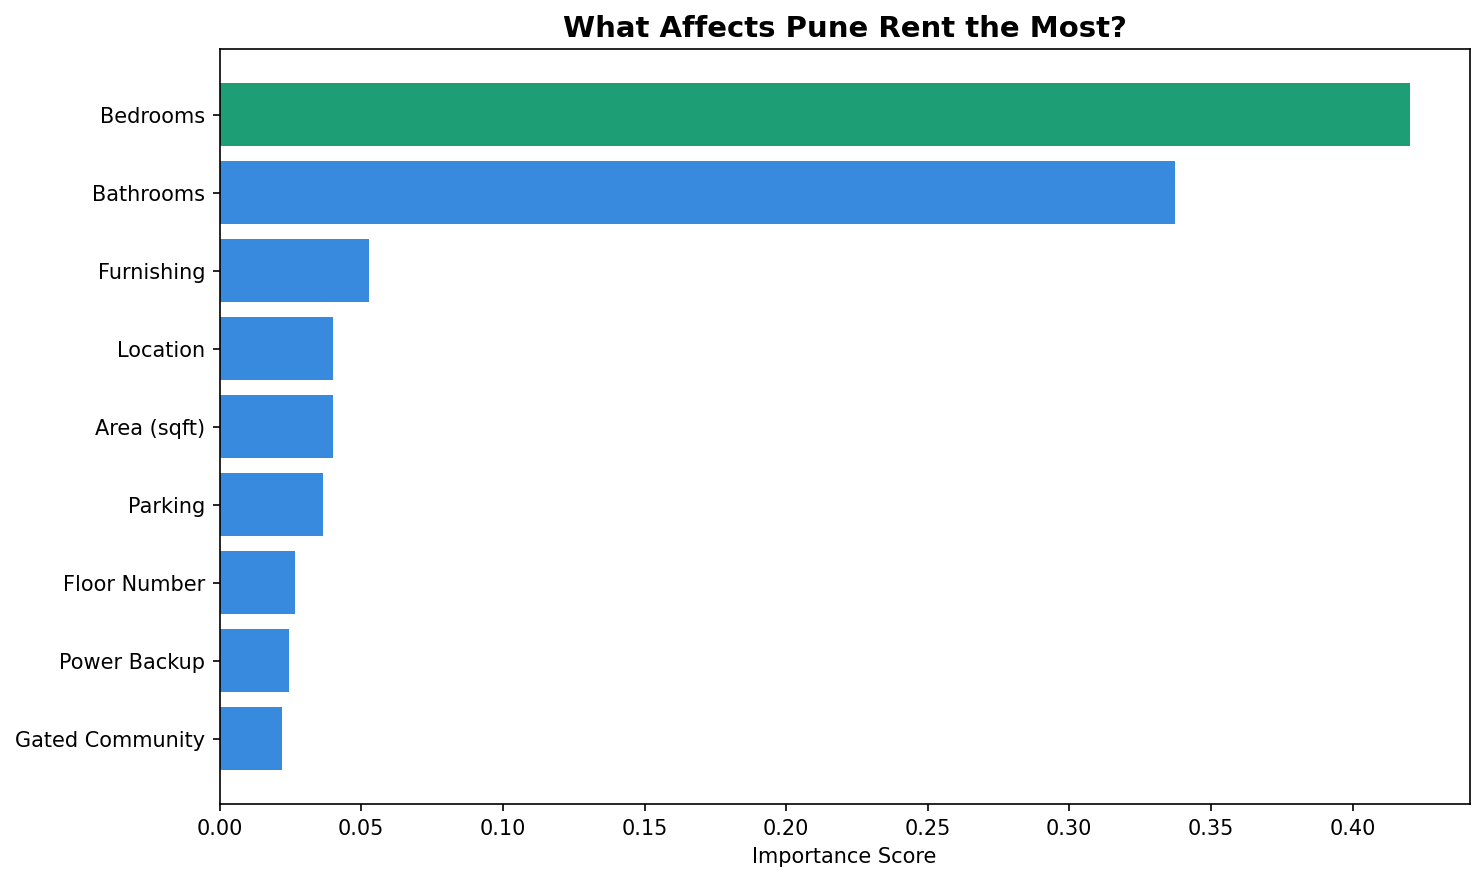

In [2]:
# Get feature importance
importance = model_final.feature_importances_
feature_names = ['Bedrooms', 'Bathrooms', 'Area (sqft)', 
                 'Furnishing', 'Floor Number',
                 'Parking', 'Power Backup', 'Gated Community',
                 'Location']

# Sort by importance
sorted_idx = np.argsort(importance)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = importance[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features, sorted_importance, 
                color=['#378ADD' if x < max(sorted_importance) 
                       else '#1D9E75' for x in sorted_importance])
plt.title('What Affects Pune Rent the Most?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("C:/Projects/pune-rent-predictor/models/feature_importance.png", 
            dpi=150, bbox_inches='tight')
plt.close()

print("Feature importance chart saved!")
print("\nRanking — what affects rent most:")
for feat, imp in sorted(zip(feature_names, importance), 
                         key=lambda x: x[1], reverse=True):
    bar = "█" * int(imp * 100)
    print(f"  {feat:<20} {bar} {imp:.4f}")

IPImage("C:/Projects/pune-rent-predictor/models/feature_importance.png")